# Rossmann Retail Price Elasticity

## Objective

The objective of this project is to analyze how promotions, store characteristics, holidays, and customer traffic influence daily retail sales across Rossmann stores. This project uses statistical analysis and machine learning to evaluate promotion effectiveness, identify key sales drivers, and build predictive models for store-level sales forecasting.

The final goal is to create a data-driven retail analytics workflow that can help business teams understand which factors increase sales and how promotions can be evaluated more effectively.

---

## Business Questions

This project is designed to answer the following business questions:

1. Do promotions significantly increase sales?
2. Do promotions increase customer traffic?
3. Which store types generate the highest average sales?
4. Do different assortment levels affect sales performance?
5. Does competition distance influence store sales?
6. How do holidays and school holidays impact sales patterns?
7. What are the strongest predictors of daily sales?
8. How accurately can machine learning models forecast sales?

---

## Data Profile

This project uses the Rossmann Store Sales dataset, which contains historical daily sales data for Rossmann drug stores.

### Dataset Files

#### train.csv

The training dataset contains daily store-level sales records.

Key columns include:

- Store: Unique store identifier
- DayOfWeek: Day of the week
- Date: Sales date
- Sales: Daily sales revenue
- Customers: Number of customers visiting the store
- Open: Indicates whether the store was open
- Promo: Indicates whether a promotion was active
- StateHoliday: Indicates whether the date was a state holiday
- SchoolHoliday: Indicates whether the date was a school holiday

#### store.csv

The store dataset contains additional store-level attributes.

Key columns include:

- Store: Unique store identifier
- StoreType: Store format/category
- Assortment: Product assortment level
- CompetitionDistance: Distance to the nearest competitor
- CompetitionOpenSinceMonth: Month the nearest competitor opened
- CompetitionOpenSinceYear: Year the nearest competitor opened
- Promo2: Indicates whether the store participates in an ongoing promotion program
- Promo2SinceWeek: Week the ongoing promotion program started
- Promo2SinceYear: Year the ongoing promotion program started
- PromoInterval: Months when Promo2 is active

---

## Analytical Approach

The project will follow these steps:

1. Load and merge the train and store datasets.
2. Clean the data by handling missing values and removing closed-store records.
3. Create date-based features such as year, month, week, and day.
4. Explore sales patterns across promotions, store types, holidays, and competition distance.
5. Use hypothesis testing to evaluate whether promotions and store characteristics significantly affect sales.
6. Use OLS regression to explain key sales drivers.
7. Build machine learning models to forecast daily sales.
8. Evaluate model performance using MAE, RMSE, and R².

## Importing Packages

In [1]:
## Importing the Necessary Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind, f_oneway
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

## Importing Necessary Datasets

In [2]:
## Importing the Correct Datasets
store = pd.read_csv("store.csv")
train = pd.read_csv("train.csv")

## MERGE DATASETS
df = train.merge(store,how="left")
df.head()

C:\Users\muzam\AppData\Local\Temp\ipykernel_34876\1474691876.py:3: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("train.csv")


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


## Data Overview

In [3]:
# Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionO

In [4]:
# Looking at Null Values
(df.isnull().sum() / len(df)) * 100

Store                         0.000000
DayOfWeek                     0.000000
Date                          0.000000
Sales                         0.000000
Customers                     0.000000
Open                          0.000000
Promo                         0.000000
StateHoliday                  0.000000
SchoolHoliday                 0.000000
StoreType                     0.000000
Assortment                    0.000000
CompetitionDistance           0.259730
CompetitionOpenSinceMonth    31.787764
CompetitionOpenSinceYear     31.787764
Promo2                        0.000000
Promo2SinceWeek              49.943620
Promo2SinceYear              49.943620
PromoInterval                49.943620
dtype: float64

In [5]:
# Describe
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Store,1017209.0,558.429727,321.908651,1.0,280.0,558.0,838.0,1115.0
DayOfWeek,1017209.0,3.998341,1.997391,1.0,2.0,4.0,6.0,7.0
Sales,1017209.0,5773.818972,3849.926175,0.0,3727.0,5744.0,7856.0,41551.0
Customers,1017209.0,633.145946,464.411734,0.0,405.0,609.0,837.0,7388.0
Open,1017209.0,0.830107,0.375539,0.0,1.0,1.0,1.0,1.0
Promo,1017209.0,0.381515,0.485759,0.0,0.0,0.0,1.0,1.0
SchoolHoliday,1017209.0,0.178647,0.383056,0.0,0.0,0.0,0.0,1.0
CompetitionDistance,1014567.0,5430.085652,7715.323700,20.0,710.0,2330.0,6890.0,75860.0
CompetitionOpenSinceMonth,693861.0,7.222866,3.211832,1.0,4.0,8.0,10.0,12.0
CompetitionOpenSinceYear,693861.0,2008.690228,5.992644,1900.0,2006.0,2010.0,2013.0,2015.0


## Missing Value Treatment

In [6]:
# Filling in Missing Values
df['CompetitionDistance'] = df['CompetitionDistance'].fillna(df['CompetitionDistance'].median()) ## COMPETITIONDISTANCE
df['CompetitionOpenSinceMonth'] = (df['CompetitionOpenSinceMonth'].fillna(0)) ## COMPETITONOPENSINCEMONTH
df['CompetitionOpenSinceYear'] = (df['CompetitionOpenSinceYear'].fillna(0)) ##COMPETITIONOVERSINCEYEAR
df['Promo2SinceWeek'] = (df['Promo2SinceWeek'].fillna(0)) ## PROMO2INFORMATION
df['Promo2SinceYear'] = (df['Promo2SinceYear'].fillna(0)) ## PROMO2SINCEYEAR
df['PromoInterval'] = (df['PromoInterval'].fillna('None')) ## PROMOINTERVAL

df.isnull().sum()

Store                        0
DayOfWeek                    0
Date                         0
Sales                        0
Customers                    0
Open                         0
Promo                        0
StateHoliday                 0
SchoolHoliday                0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
dtype: int64

## Data Cleaning

In [7]:
# Data Cleaning
df = df[df["Open"] == 1] #FILTER FOR OPEN STORES 
df = df[df["Sales"] > 0] #FILTER OUT 0 SALES
df["Date"] = pd.to_datetime(df["Date"]) #CONVERT TO DATETIME

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 844338 entries, 0 to 1017190
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Store                      844338 non-null  int64         
 1   DayOfWeek                  844338 non-null  int64         
 2   Date                       844338 non-null  datetime64[ns]
 3   Sales                      844338 non-null  int64         
 4   Customers                  844338 non-null  int64         
 5   Open                       844338 non-null  int64         
 6   Promo                      844338 non-null  int64         
 7   StateHoliday               844338 non-null  object        
 8   SchoolHoliday              844338 non-null  int64         
 9   StoreType                  844338 non-null  object        
 10  Assortment                 844338 non-null  object        
 11  CompetitionDistance        844338 non-null  float64     

## Feature Engineering

In [8]:
# Breaking down datetime
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Week'] = df['Date'].dt.isocalendar().week

# Sales per Customer
df['SalesPerCustomer'] = df['Sales']/df['Customers']

df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,Week,SalesPerCustomer
0,1,5,2015-07-31,5263,555,1,1,0,1,c,...,2008.0,0,0.0,0.0,None,2015,7,31,31,9.482883
1,2,5,2015-07-31,6064,625,1,1,0,1,a,...,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,31,9.702400
2,3,5,2015-07-31,8314,821,1,1,0,1,a,...,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,31,10.126675
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,...,2009.0,0,0.0,0.0,None,2015,7,31,31,9.342457
4,5,5,2015-07-31,4822,559,1,1,0,1,a,...,2015.0,0,0.0,0.0,None,2015,7,31,31,8.626118


## Exploratory Data Analysis (EDA)

### Sales Distribution

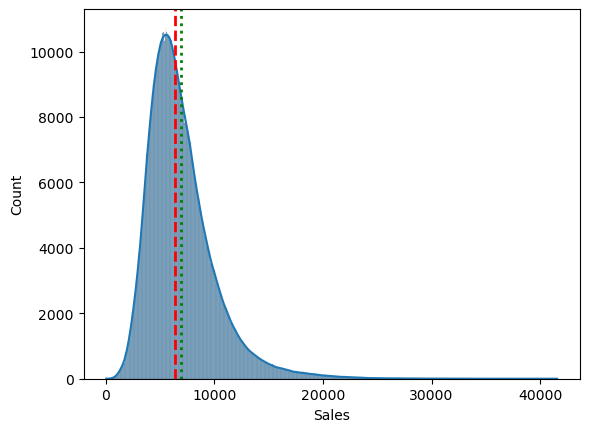

In [9]:
# Sales Distribution
mean_value = np.mean(df['Sales'])
median_value = np.median(df['Sales'])

# Making the histogram
sns.histplot(df,x='Sales',kde=True)
#Adding the mean and median lines
plt.axvline(median_value, color="red", linestyle="--", linewidth=2, label=f"Median = {median_value:.2f}")
plt.axvline(mean_value, color="green", linestyle=":", linewidth=2, label=f"Mean = {mean_value:.2f}")
plt.show()

### Time Series Analysis

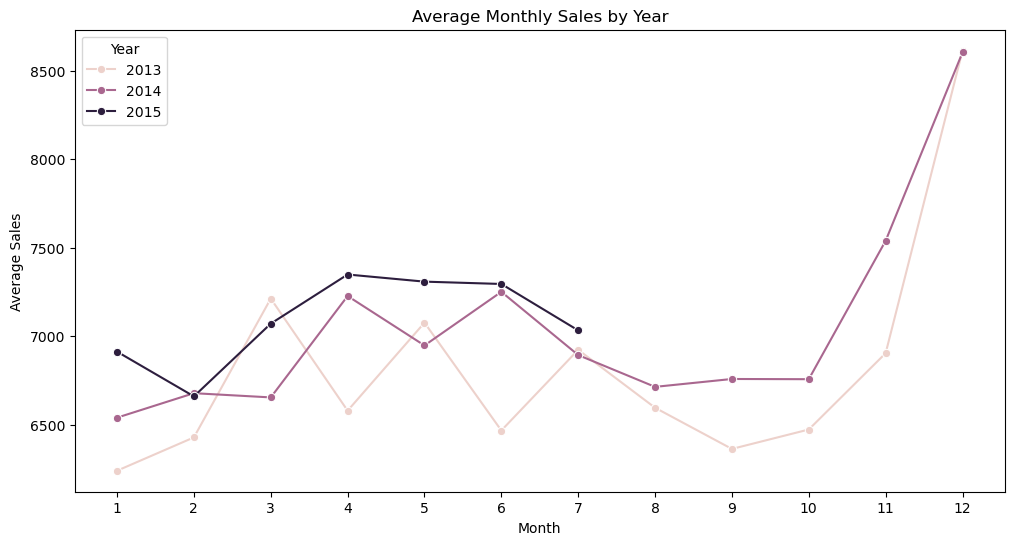

In [10]:
# Monthly Sales Trend Comparing Each Year
monthly_year_sales = (
    df.groupby(['Year','Month'])['Sales']
      .mean()
      .reset_index()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_year_sales,
    x='Month',
    y='Sales',
    hue='Year',
    marker='o'
)

plt.title('Average Monthly Sales by Year')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.xticks(range(1,13))

plt.show()

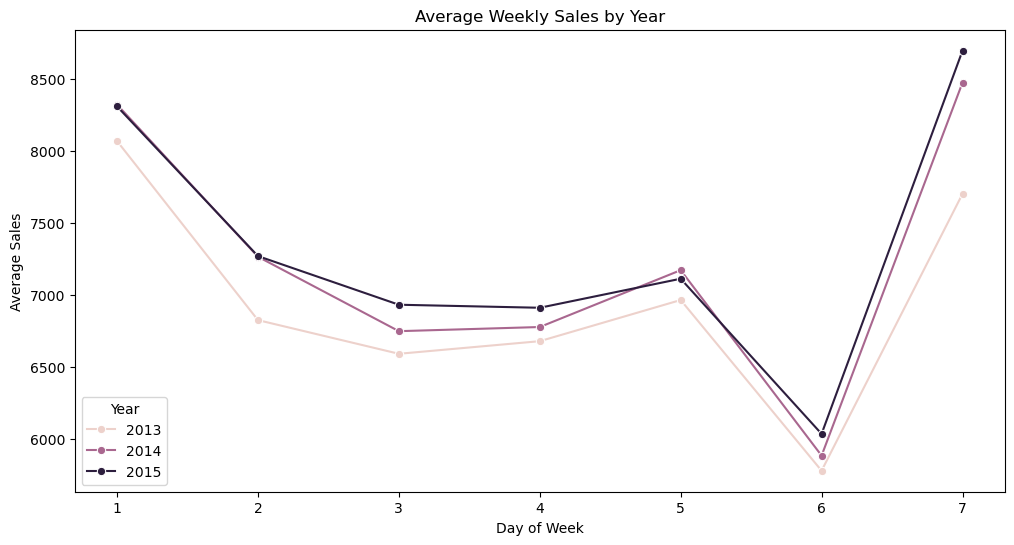

In [11]:
# Better look at Per Day of Week
weekly_sales = (df.groupby(['Year','DayOfWeek'])['Sales'].mean().reset_index())

plt.figure(figsize=(12,6))

sns.lineplot(
    data=weekly_sales,
    x='DayOfWeek',
    y='Sales',
    hue='Year',
    marker='o'
)

plt.title('Average Weekly Sales by Year')
plt.xlabel('Day of Week')
plt.ylabel('Average Sales')
plt.xticks(range(1,8))

plt.show()

### Promotional Effectiveness Analysis

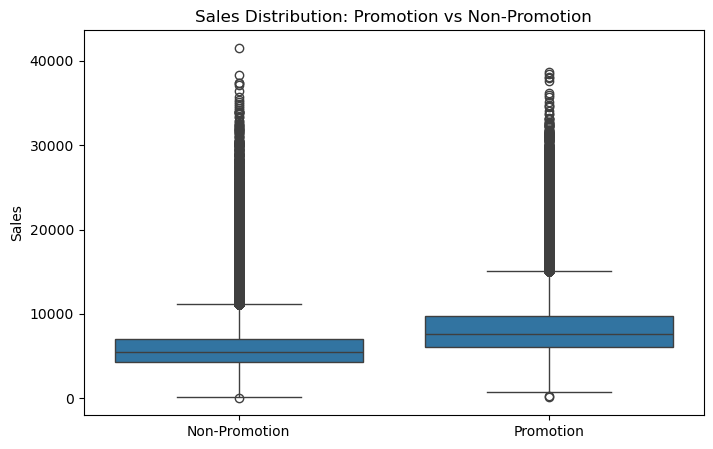

In [12]:
# Promotional vs Nonpromotional 
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Promo',
    y='Sales'
)

plt.xticks([0,1], ['Non-Promotion', 'Promotion'])

plt.title('Sales Distribution: Promotion vs Non-Promotion')
plt.xlabel('')
plt.ylabel('Sales')

plt.show()

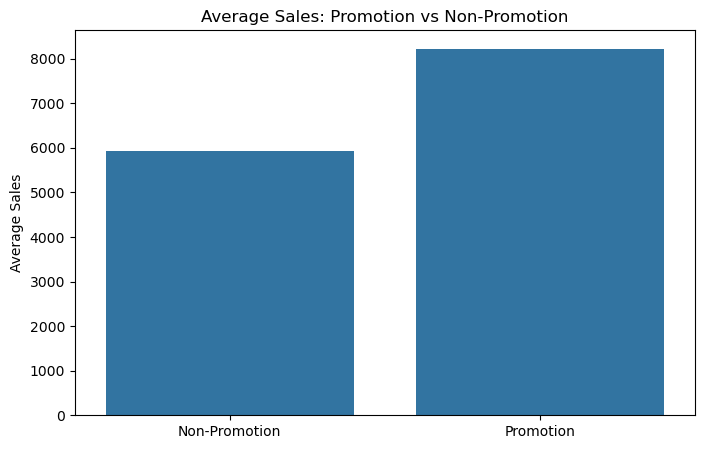

In [13]:
# Average sales by promotion status
promo_sales = (
    df.groupby('Promo')['Sales']
    .mean()
    .reset_index()
)

promo_sales

plt.figure(figsize=(8,5))
sns.barplot(data=promo_sales, x='Promo', y='Sales')
plt.xticks([0,1], ['Non-Promotion', 'Promotion'])
plt.title('Average Sales: Promotion vs Non-Promotion')
plt.xlabel('')
plt.ylabel('Average Sales')
plt.show()

In [14]:
# Promotional Lift
non_promo_avg = df[df['Promo'] == 0]['Sales'].mean()
promo_avg = df[df['Promo'] == 1]['Sales'].mean()

promo_lift = ((promo_avg - non_promo_avg) / non_promo_avg) * 100

print(f"Promotion Lift: {promo_lift:.2f}%")

Promotion Lift: 38.77%


### Customer Traffic Performance

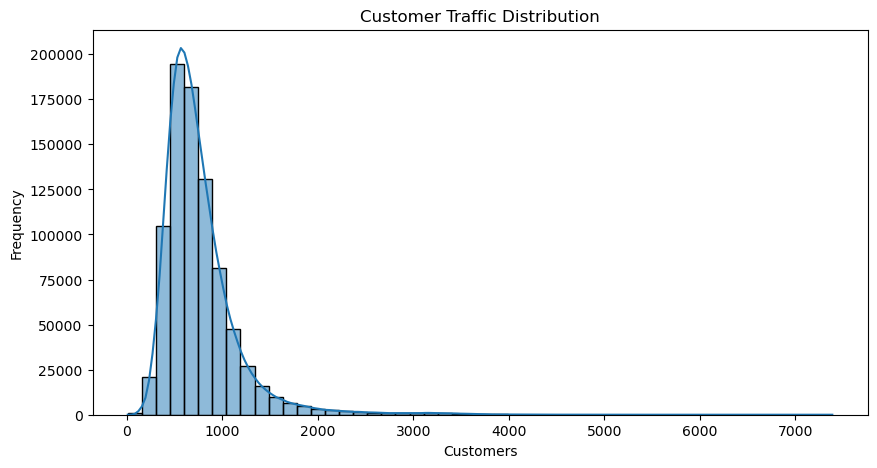

In [15]:
# Customer distribution
plt.figure(figsize=(10,5))
sns.histplot(df['Customers'], bins=50, kde=True)
plt.title('Customer Traffic Distribution')
plt.xlabel('Customers')
plt.ylabel('Frequency')
plt.show()

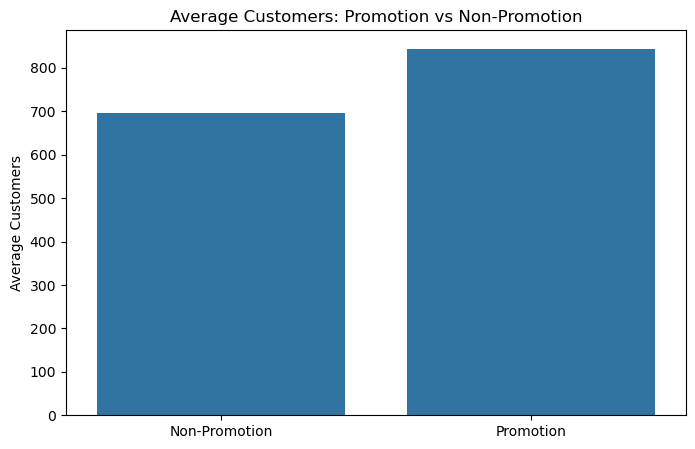

In [16]:
# Customers by promotion status
promo_customers = (
    df.groupby('Promo')['Customers']
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))
sns.barplot(data=promo_customers, x='Promo', y='Customers')
plt.xticks([0,1], ['Non-Promotion', 'Promotion'])
plt.title('Average Customers: Promotion vs Non-Promotion')
plt.xlabel('')
plt.ylabel('Average Customers')
plt.show()

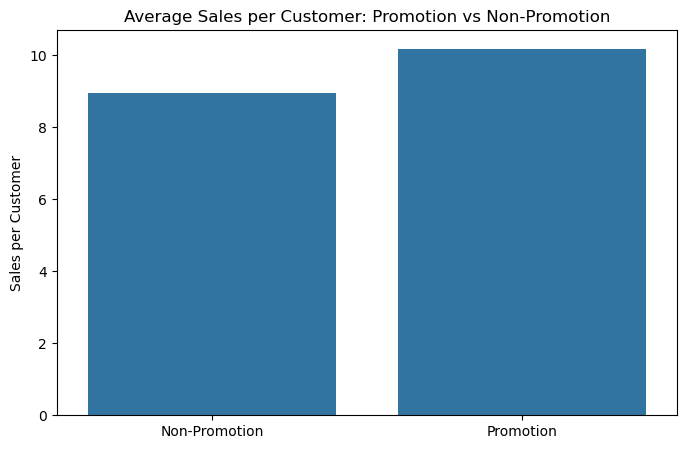

In [17]:
# Sales per customer by promotion
promo_spc = (
    df.groupby('Promo')['SalesPerCustomer']
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))
sns.barplot(data=promo_spc, x='Promo', y='SalesPerCustomer')
plt.xticks([0,1], ['Non-Promotion', 'Promotion'])
plt.title('Average Sales per Customer: Promotion vs Non-Promotion')
plt.xlabel('')
plt.ylabel('Sales per Customer')
plt.show()

### Store Performance Analysis

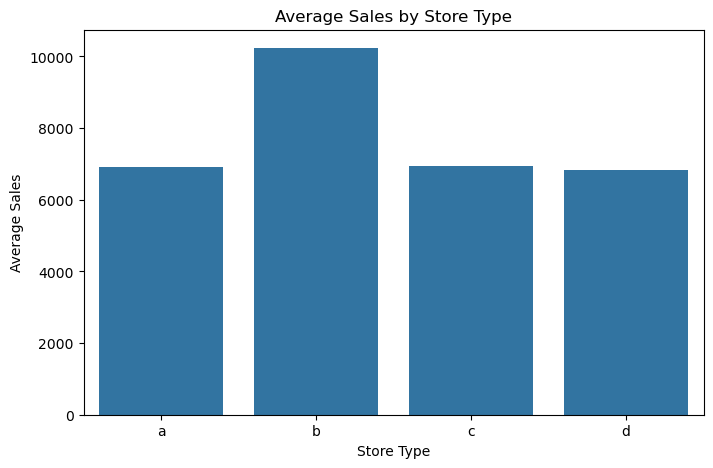

In [18]:
# Store Type Performance
store_sales = (
    df.groupby('StoreType')['Sales']
      .mean()
      .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=store_sales,
    x='StoreType',
    y='Sales'
)

plt.title('Average Sales by Store Type')
plt.xlabel('Store Type')
plt.ylabel('Average Sales')

plt.show()

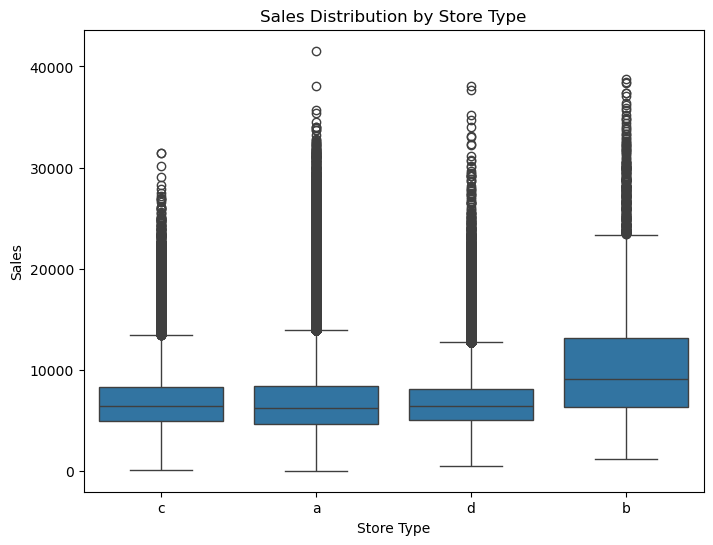

In [19]:
# Boxplot of Store Average Sales
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='StoreType',
    y='Sales'
)

plt.title('Sales Distribution by Store Type')
plt.xlabel('Store Type')
plt.ylabel('Sales')

plt.show()

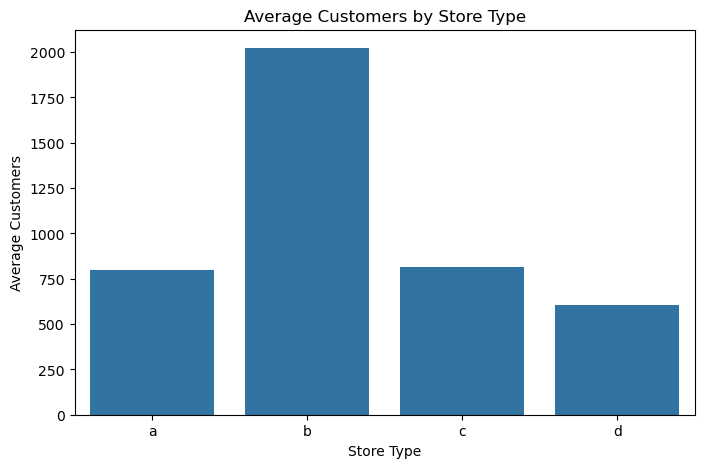

In [20]:
# Customers by store type
store_type_customers = (
    df.groupby('StoreType')['Customers']
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))
sns.barplot(data=store_type_customers, x='StoreType', y='Customers')
plt.title('Average Customers by Store Type')
plt.xlabel('Store Type')
plt.ylabel('Average Customers')
plt.show()

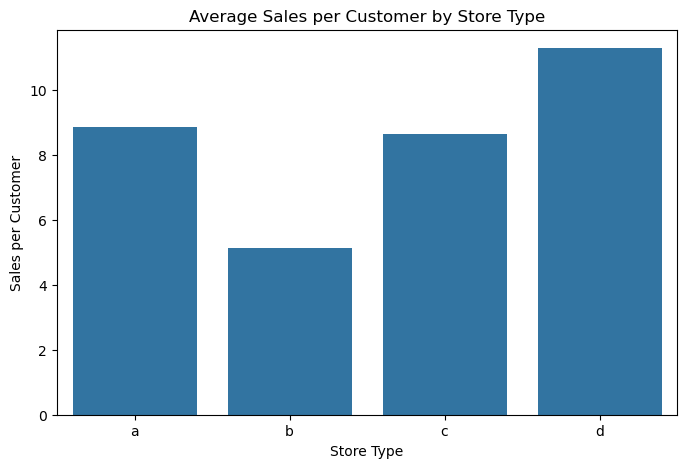

In [21]:
# Sales per customer by store type
store_type_spc = (
    df.groupby('StoreType')['SalesPerCustomer']
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))
sns.barplot(data=store_type_spc, x='StoreType', y='SalesPerCustomer')
plt.title('Average Sales per Customer by Store Type')
plt.xlabel('Store Type')
plt.ylabel('Sales per Customer')
plt.show()

### Assortment Analysis

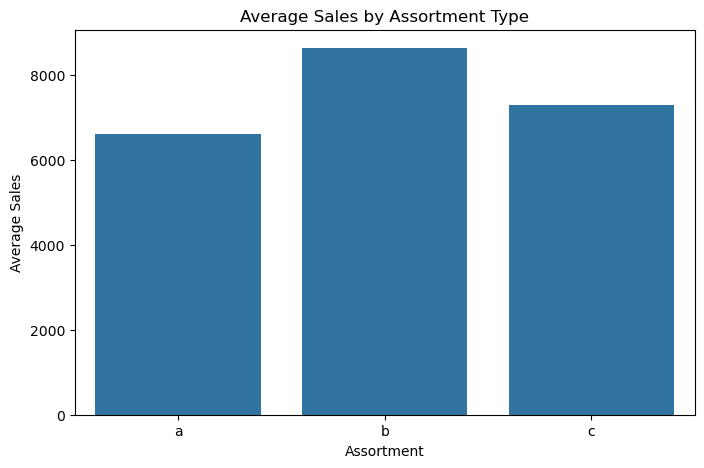

In [22]:
# Average sales by assortment
assortment_sales = (
    df.groupby('Assortment')['Sales']
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))
sns.barplot(data=assortment_sales, x='Assortment', y='Sales')
plt.title('Average Sales by Assortment Type')
plt.xlabel('Assortment')
plt.ylabel('Average Sales')
plt.show()

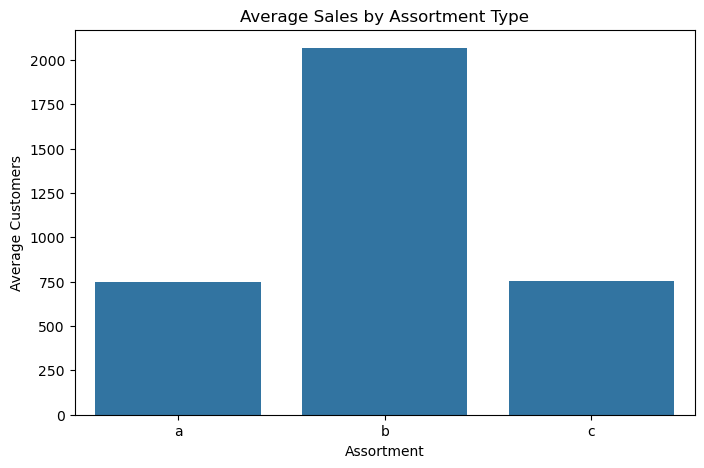

In [23]:
# Average Assortment by Customer
assortment_customers = (df.groupby('Assortment')['Customers'].mean().reset_index())
plt.figure(figsize=(8,5))
sns.barplot(data=assortment_customers, x='Assortment', y='Customers')
plt.title('Average Sales by Assortment Type')
plt.xlabel('Assortment')
plt.ylabel('Average Customers')
plt.show()

### Competition Distance Analysis

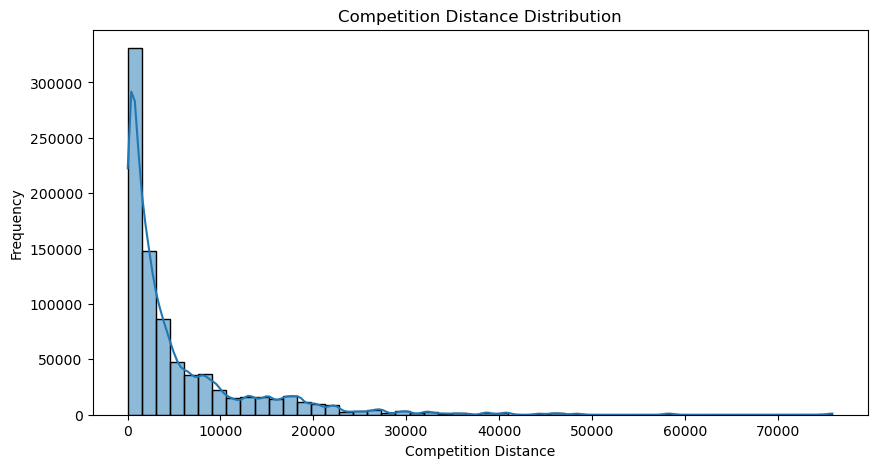

In [24]:
# Competition distance distribution
plt.figure(figsize=(10,5))
sns.histplot(df['CompetitionDistance'], bins=50, kde=True)
plt.title('Competition Distance Distribution')
plt.xlabel('Competition Distance')
plt.ylabel('Frequency')
plt.show()

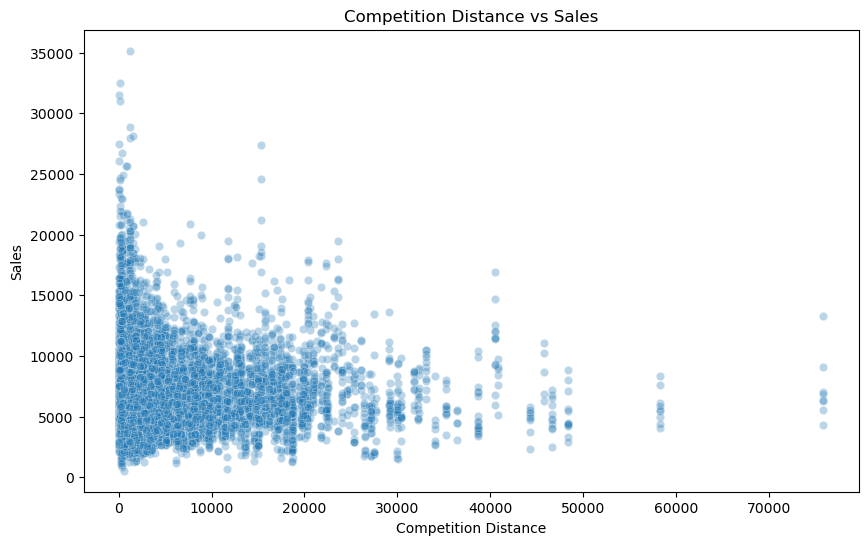

In [25]:
# Competition distance vs sales
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df.sample(10000, random_state=42),
    x='CompetitionDistance',
    y='Sales',
    alpha=0.3
)
plt.title('Competition Distance vs Sales')
plt.xlabel('Competition Distance')
plt.ylabel('Sales')
plt.show()

### Holiday Analysis

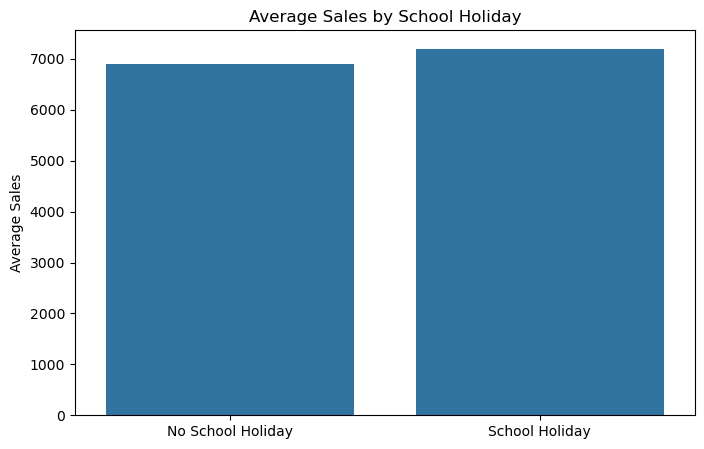

In [26]:
# Sales by school holiday
school_holiday_sales = (
    df.groupby('SchoolHoliday')['Sales']
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))
sns.barplot(data=school_holiday_sales, x='SchoolHoliday', y='Sales')
plt.xticks([0,1], ['No School Holiday', 'School Holiday'])
plt.title('Average Sales by School Holiday')
plt.xlabel('')
plt.ylabel('Average Sales')
plt.show()

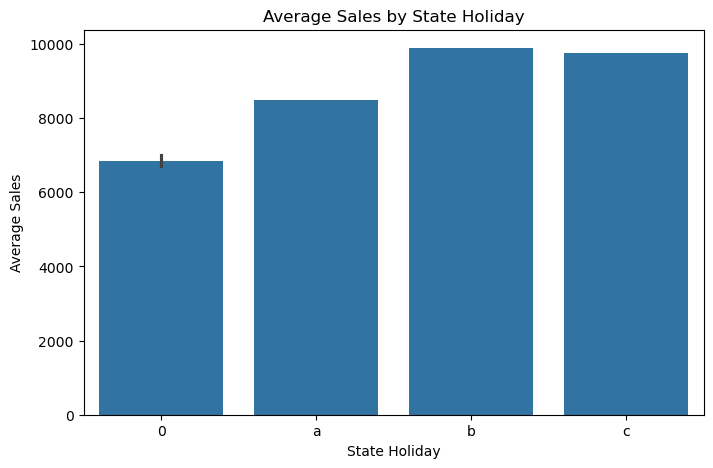

In [27]:
# Sales by state holiday
state_holiday_sales = (
    df.groupby('StateHoliday')['Sales']
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))
sns.barplot(data=state_holiday_sales, x='StateHoliday', y='Sales')
plt.title('Average Sales by State Holiday')
plt.xlabel('State Holiday')
plt.ylabel('Average Sales')
plt.show()

### Correlation Analysis

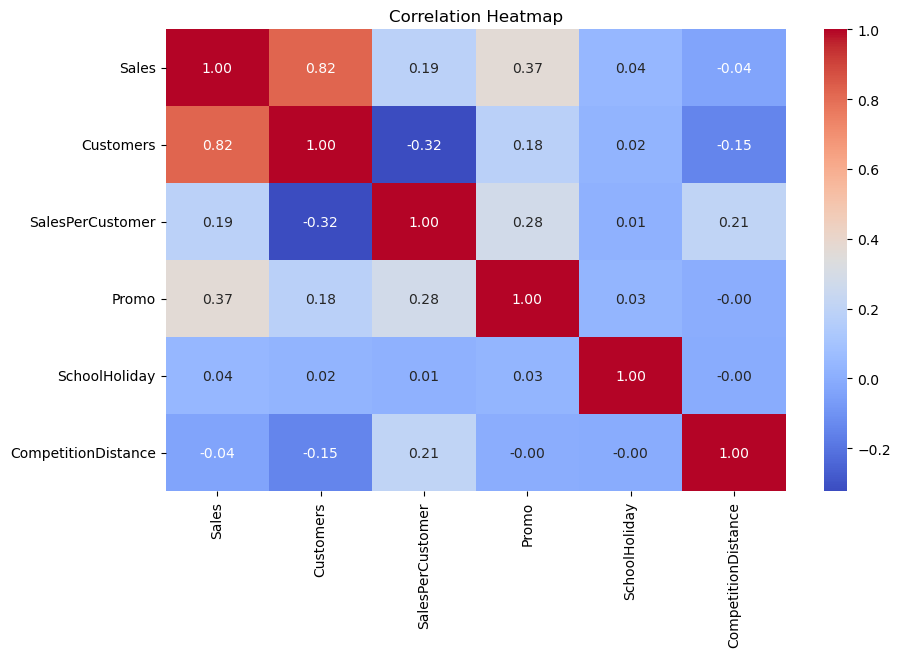

In [28]:
# Correlation heatmap
corr_cols = [
    'Sales',
    'Customers',
    'SalesPerCustomer',
    'Promo',
    'SchoolHoliday',
    'CompetitionDistance'
]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

**EDA Summary**
* Sales are right skewed, which is an indicator that majority of stores are making moderate to slow sales
* Monthly and weekly sales are showing a consistent pattern and yearly and weekly growth
* Sales and Customer Traffic in stores do have an effect by promotions
* Store performance varies by store type and assortment level
* Customer Traffic is strongly related to sales, hence the 0.82 positive correlation coefficient
* Competition Distance and holidays may also influence store performance

## Hypothesis Testing

### Do promotions significantly increase sales at stores?
H₀: Average sales during promotions are equal to average sales during non-promotional periods.

H₁: Average sales differ between promotional and non-promotional periods.

In [29]:
# First Make the means for promotions
promo_sales = df[df['Promo']==1]['Sales']
nonpromo_sales = df[df['Promo']==0]['Sales']

# Ttest
t_stat,p_value = ttest_ind(promo_sales,nonpromo_sales,equal_var=False)

print('t-statistic:',t_stat)
print('P-Value:',p_value)

if p_value < 0.05:
    print("We reject Null Hypothesis")
else:
    print("We FAIL TO REJECT Null Hypothesis")

t-statistic: 356.6859122343584
P-Value: 0.0
We reject Null Hypothesis


The p-value was less than 0.05, indicating that promotions have a statistically significant effect on sales. Therefore, the null hypothesis was rejected, suggesting that promotional campaigns contribute to increased store revenue.

### Do Promotions Increase Customer Traffic?
H₀: The average number of customers is the same during promotional and non-promotional periods.

H₁: Promotions affect customer traffic.

In [30]:
promo_customers = df[df['Promo']==1]['Customers']
nonpromo_customers = df[df['Promo']==0]['Customers']

#Ttest
t_stat, p_value = ttest_ind(promo_customers,nonpromo_customers,equal_var=False)

print("T-statistic:",t_stat)
print("P-value:",p_value)

if p_value < 0.05:
    print("We reject Null Hypothesis")
else:
    print("We FAIL TO REJECT Null Hypothesis")

T-statistic: 170.33544999512955
P-value: 0.0
We reject Null Hypothesis


A p-value below 0.05 indicates that promotions significantly influence customer traffic. Promotional campaigns are associated with higher customer counts compared to non-promotional periods.

### Do Store Types Have Different Average Sales?
H₀: All store types have equal average sales.

H₁: At least one store type has a different average sales level.

In [31]:
a = df[df['StoreType']=='a']['Sales']
b = df[df['StoreType']=='b']['Sales']
c = df[df['StoreType']=='c']['Sales']
d = df[df['StoreType']=='d']['Sales']

# One-Way Test
f_stat, p_value = f_oneway(a,b,c,d)

print("F-statistic:",f_stat)
print("P-value:",p_value)

if p_value < 0.05:
    print("We reject Null Hypothesis")
else:
    print("We FAIL TO REJECT Null Hypothesis")

F-statistic: 6088.47865731549
P-value: 0.0
We reject Null Hypothesis


Since the p-value was below 0.05, the null hypothesis was rejected. This suggests that average sales differ significantly among store types, indicating that store format is an important determinant of store performance.

### Does Assortment Level Affect Sales?
H₀: Average sales are equal across assortment levels.

H₁: At least one assortment level differs.

In [32]:
a = df[df['Assortment']=='a']['Sales']
b = df[df['Assortment']=='b']['Sales']
c = df[df['Assortment']=='c']['Sales']

# One-Way Test
f_stat, p_value = f_oneway(a,b,c)

print("F-statistic:",f_stat)
print("P-value:",p_value)

if p_value < 0.05:
    print("We reject Null Hypothesis")
else:
    print("We FAIL TO REJECT Null Hypothesis")

F-statistic: 6302.46730085997
P-value: 0.0
We reject Null Hypothesis


The results indicate that assortment level significantly influences sales performance. Stores offering different assortment levels generate different average revenues.

### Do School Holidays Affect Sales?

H₀: Sales during school holidays are equal to sales during non-school holiday periods.

H₁: School holidays affect sales.

In [33]:
holiday_sales = df[df['SchoolHoliday']==1]['Sales']
nonholiday_sales = df[df['SchoolHoliday']==0]['Sales']

#Ttest 
t_stat, p_value = ttest_ind(holiday_sales, nonholiday_sales, equal_var=False)

print("T-statistic:",t_stat)
print("P-value:",p_value)

if p_value < 0.05:
    print("We reject Null Hypothesis")
else:
    print("We FAIL TO REJECT Null Hypothesis")

T-statistic: 34.889786293400654
P-value: 4.8716676874566964e-266
We reject Null Hypothesis


A statistically significant p-value indicates that school holidays influence consumer demand and sales patterns.

### Does Competition Distance Influence Sales?

H₀: There is no linear relationship between competition distance and sales.

H₁: Competition distance and sales are linearly related.

In [34]:
from scipy.stats import pearsonr

# Pearson Test
corr, p_value = pearsonr( df['CompetitionDistance'],df['Sales'])

print("Correlation:",corr)
print("P-value:",p_value)

if p_value < 0.05:
    print("We reject Null Hypothesis")
else:
    print("We FAIL TO REJECT Null Hypothesis")

Correlation: -0.03590840664795156
P-value: 6.648054611298062e-239
We reject Null Hypothesis


A statistically significant correlation indicates that proximity to competitors is associated with store sales performance.

## OLS Regression Analysis

In [35]:
# Competition Open Duration

# Replace missing values
df["CompetitionOpenSinceMonth"] = df["CompetitionOpenSinceMonth"].fillna(0)
df["CompetitionOpenSinceYear"] = df["CompetitionOpenSinceYear"].fillna(0)

# Duration in months
df["CompetitionOpenDuration"] = np.where(
    (df["CompetitionOpenSinceYear"] == 0) |
    (df["CompetitionOpenSinceMonth"] == 0),
    0,
    (
        (df["Year"] - df["CompetitionOpenSinceYear"]) * 12 +
        (df["Month"] - df["CompetitionOpenSinceMonth"])
    )
)

# Prevent negative durations
df["CompetitionOpenDuration"] = df["CompetitionOpenDuration"].clip(lower=0)

# Promo2 Duration

# Replace missing values
df["Promo2SinceWeek"] = df["Promo2SinceWeek"].fillna(0)
df["Promo2SinceYear"] = df["Promo2SinceYear"].fillna(0)

# Duration in weeks
df["Promo2Duration"] = np.where(
    (df["Promo2SinceYear"] == 0) |
    (df["Promo2SinceWeek"] == 0),
    0,
    (
        (df["Year"] - df["Promo2SinceYear"]) * 52 +
        (df["Week"] - df["Promo2SinceWeek"])
    )
)

# Prevent negative durations
df["Promo2Duration"] = df["Promo2Duration"].clip(lower=0)

# Creating Log Sales
df["LogSales"] = np.log(df["Sales"])

# Creating Dummy Variables
df_ols = pd.get_dummies(
    df,
    columns=["StoreType", "Assortment", "StateHoliday"],
    drop_first=True,
    dtype=int
)

# Independent Variables
features = [
    "Store",
    "DayOfWeek",
    "Promo",
    "Promo2",
    "Promo2Duration",
    "SchoolHoliday",
    "StateHoliday_a",
    "StateHoliday_b",
    "Month",
    "Year",
    "CompetitionDistance",
    "StoreType_b",
    "StoreType_c",
    "StoreType_d",
    "Assortment_b",
    "Assortment_c"
]


# X and y
X = df_ols[features]
y = df_ols["LogSales"]

# Convert to numeric
X = X.astype(float)
y = y.astype(float)

# Add constant
X = sm.add_constant(X)

# Fit OLS Model
ols_model = sm.OLS(y, X).fit()

# Show Results
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:               LogSales   R-squared:                       0.229
Model:                            OLS   Adj. R-squared:                  0.229
Method:                 Least Squares   F-statistic:                 1.567e+04
Date:                Tue, 30 Jun 2026   Prob (F-statistic):               0.00
Time:                        14:49:29   Log-Likelihood:            -3.6639e+05
No. Observations:              844338   AIC:                         7.328e+05
Df Residuals:                  844321   BIC:                         7.330e+05
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                 -42.4182    

### Key Metrics Interpretation

In [36]:
# Coefficients 
coef_table = pd.DataFrame({
    'Coefficient': ols_model.params,
    'P-value': ols_model.pvalues
})

coef_table

,Coefficient,P-value
const,-42.418198,1.357064e-300
Store,0.000003,7.777931e-03
DayOfWeek,-0.021410,0.000000e+00
Promo,0.325275,0.000000e+00
Promo2,-0.130119,0.000000e+00
Promo2Duration,0.000279,0.000000e+00
SchoolHoliday,0.014619,2.362328e-44
StateHoliday_a,-0.100174,1.967178e-12
StateHoliday_b,-0.128149,3.776238e-05
Month,0.009640,0.000000e+00


In [37]:
# Confidence Intervals
ols_model.conf_int()

,0,1
const,-4.466078e+01,-40.175621
Store,8.895496e-07,0.000006
DayOfWeek,-2.189749e-02,-0.020922
Promo,3.236001e-01,0.326949
Promo2,-1.324053e-01,-0.127833
Promo2Duration,2.646247e-04,0.000293
SchoolHoliday,1.256846e-02,0.016670
StateHoliday_a,-1.280756e-01,-0.072273
StateHoliday_b,-1.890999e-01,-0.067197
Month,9.387816e-03,0.009892


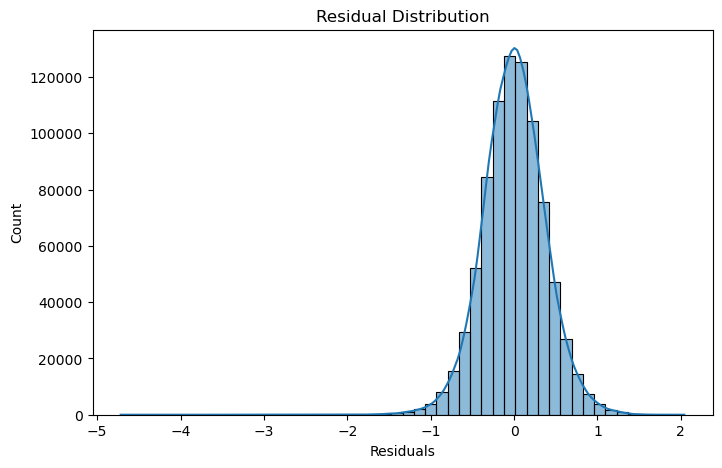

In [38]:
# Residual Analysis
plt.figure(figsize=(8,5))

sns.histplot(
    ols_model.resid,
    bins=50,
    kde=True
)

plt.title('Residual Distribution')
plt.xlabel('Residuals')

plt.show()

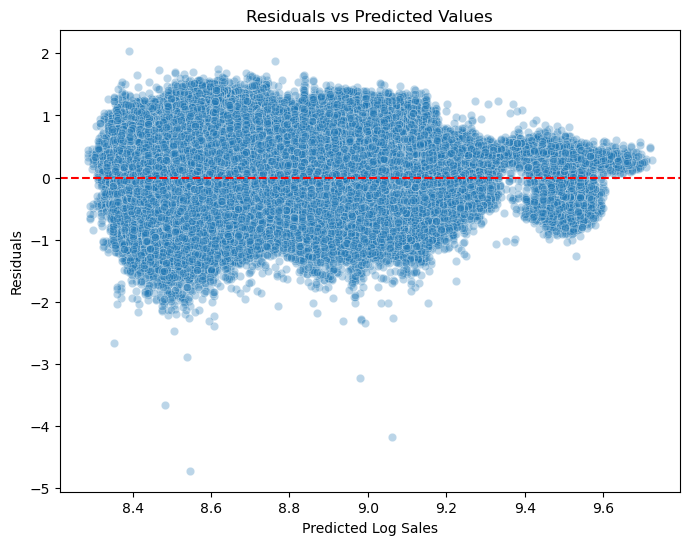

In [39]:
# Residual vs Predicted
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=ols_model.fittedvalues,
    y=ols_model.resid,
    alpha=0.3
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel('Predicted Log Sales')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')

plt.show()

**OLS Regression Insights**
* The OLS regression model identified several statistically significant predictors of sales.
* Promotional activity and customer traffic exhibited positive relationships with sales, indicating that stores running promotions and attracting more customers generally generated higher revenue.
* Store type and assortment level were also found to influence sales performance, suggesting that store characteristics play an important role in explaining differences in revenue across locations.
* Competition distance and holiday effects further contributed to sales variation, highlighting the importance of both external and seasonal factors.
* Overall, the regression model does not explain a substantial proportion of the variation in sales and provided valuable insights into the factors that drive store performance.

## Machine Learning Models

### Feature Engineering

In [40]:
df_model = df.copy()

# Final ML features
features = [
    "DayOfWeek",
    "Month",
    "Year",
    "Promo",
    "Promo2",
    "Promo2Duration",
    "SchoolHoliday",
    "StateHoliday_a",
    "StateHoliday_b",
    "StateHoliday_c",
    "CompetitionDistance",
    "CompetitionOpenDuration",
    "StoreType_b",
    "StoreType_c",
    "StoreType_d",
    "Assortment_b",
    "Assortment_c"
]

# Keep only columns that exist
features = [col for col in features if col in df_model.columns]

# Define X and y
X = df_model[features].astype(float)
y = df_model["Sales"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Scale only for Linear Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Baseline Models

In [41]:
models = {
    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        random_state=42,
        n_estimators=100,
        n_jobs=-1
    ),

    "XGBoost": XGBRegressor(
        objective="reg:squarederror",
        eval_metric="rmse",
        n_estimators=500,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
}

### Training Models and Obtaining Metrics

In [42]:
results = []

for name, model in models.items():

    if name == "Linear Regression":

        # Scaled Linear Regression
        model.fit(X_train_scaled, y_train)

        # Predictions
        train_pred = model.predict(X_train_scaled)
        test_pred = model.predict(X_test_scaled)

    else:

        # Train model
        model.fit(X_train, y_train)

        # Predictions
        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)

    # Metrics
    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    train_mae = mean_absolute_error(y_train, train_pred)
    test_mae = mean_absolute_error(y_test, test_pred)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    # Store results
    results.append({
        "Model": name,

        "Train R²": train_r2,
        "Test R²": test_r2,

        "Train MAE": train_mae,
        "Test MAE": test_mae,

        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,

        "R² Difference": abs(train_r2 - test_r2),
        "MAE Difference": abs(train_mae - test_mae),
        "RMSE Difference": abs(train_rmse - test_rmse)
    })

In [43]:
results_df = pd.DataFrame(results)

results_df

,Model,Train R²,Test R²,Train MAE,Test MAE,Train RMSE,Test RMSE,R² Difference,MAE Difference,RMSE Difference
0,Linear Regression,0.168074,0.169733,2056.441228,2055.633881,2830.403219,2830.498258,0.001659,0.807348,0.095039
1,Random Forest,0.948377,0.846231,391.865137,773.630425,705.061977,1218.116753,0.102147,381.765288,513.054776
2,XGBoost,0.752300,0.744920,1056.839844,1074.460205,1544.433634,1568.889735,0.007380,17.620361,24.456101


### Tuned Model

In [44]:
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [15, None],
    "min_samples_leaf": [1, 2],
    "min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)
print("Best RMSE:", -grid_search.best_score_)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best RMSE: 1245.9210171255304


### Tuned vs Baseline Model

In [46]:
# Fit baseline Random Forest
baseline_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

baseline_rf.fit(X_train, y_train)

# Predictions
baseline_train_pred = baseline_rf.predict(X_train)
baseline_test_pred = baseline_rf.predict(X_test)

tuned_train_pred = best_rf.predict(X_train)
tuned_test_pred = best_rf.predict(X_test)

# Comparison table
rf_comparison_df = pd.DataFrame({
    "Model": [
        "Baseline Random Forest",
        "Tuned Random Forest"
    ],

    "Train R²": [
        r2_score(y_train, baseline_train_pred),
        r2_score(y_train, tuned_train_pred)
    ],

    "Test R²": [
        r2_score(y_test, baseline_test_pred),
        r2_score(y_test, tuned_test_pred)
    ],

    "Train MAE": [
        mean_absolute_error(y_train, baseline_train_pred),
        mean_absolute_error(y_train, tuned_train_pred)
    ],

    "Test MAE": [
        mean_absolute_error(y_test, baseline_test_pred),
        mean_absolute_error(y_test, tuned_test_pred)
    ],

    "Train RMSE": [
        np.sqrt(mean_squared_error(y_train, baseline_train_pred)),
        np.sqrt(mean_squared_error(y_train, tuned_train_pred))
    ],

    "Test RMSE": [
        np.sqrt(mean_squared_error(y_test, baseline_test_pred)),
        np.sqrt(mean_squared_error(y_test, tuned_test_pred))
    ]
})

# Overfitting differences
rf_comparison_df["R² Difference"] = (
    rf_comparison_df["Train R²"] - rf_comparison_df["Test R²"]
)

rf_comparison_df["MAE Difference"] = (
    rf_comparison_df["Test MAE"] - rf_comparison_df["Train MAE"]
)

rf_comparison_df["RMSE Difference"] = (
    rf_comparison_df["Test RMSE"] - rf_comparison_df["Train RMSE"]
)

rf_comparison_df = rf_comparison_df.round(4)

rf_comparison_df

,Model,Train R²,Test R²,Train MAE,Test MAE,Train RMSE,Test RMSE,R² Difference,MAE Difference,RMSE Difference
0,Baseline Random Forest,0.9484,0.8462,391.8651,773.6304,705.0620,1218.1168,0.1021,381.7653,513.0548
1,Tuned Random Forest,0.9342,0.8545,479.2003,750.4934,796.0142,1184.7302,0.0797,271.2932,388.7160


### Actual vs Predictions 

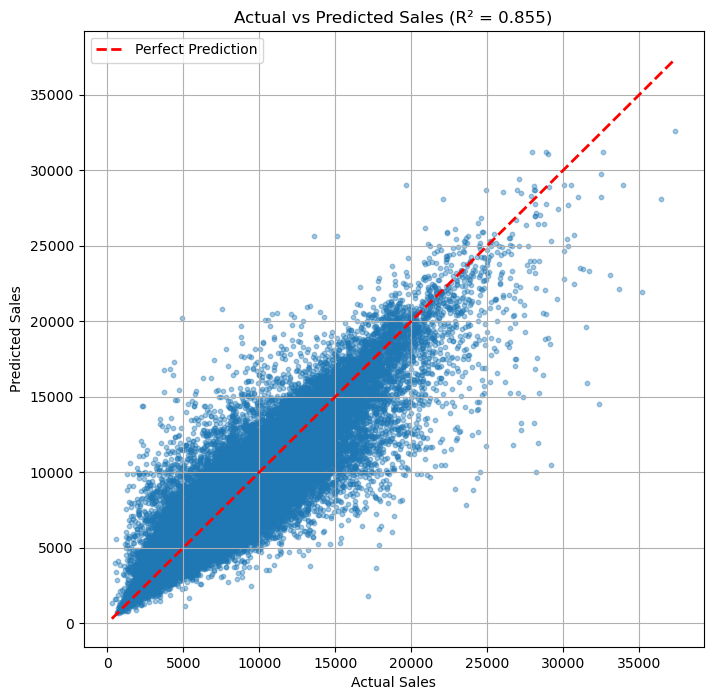

In [48]:
# Predictions from the tuned Random Forest
y_pred = best_rf.predict(X_test)

# Create figure
plt.figure(figsize=(8, 8))

# Scatter plot
plt.scatter(
    y_test,
    y_pred,
    alpha=0.4,
    s=10
)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--',
    linewidth=2,
    label='Perfect Prediction'
)

# Labels
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title(f"Actual vs Predicted Sales (R² = {r2_score(y_test, y_pred):.3f})")

plt.legend()
plt.grid(True)

plt.show()

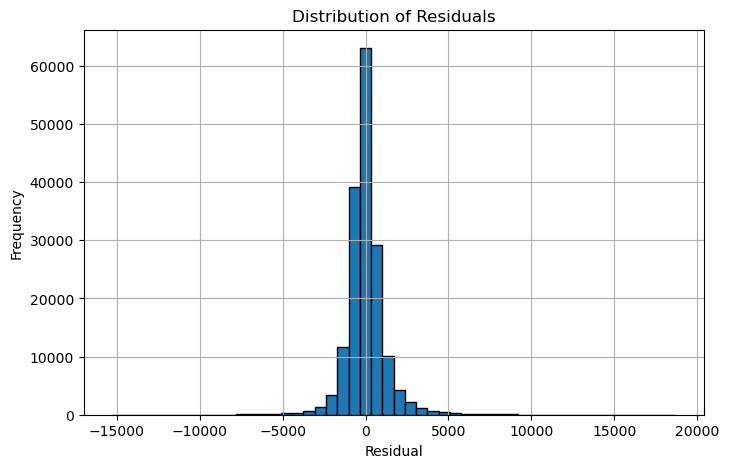

In [50]:
# Residual Distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    residuals,
    bins=50,
    edgecolor='black'
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")

plt.grid(True)

plt.show()

### Residual Analysis

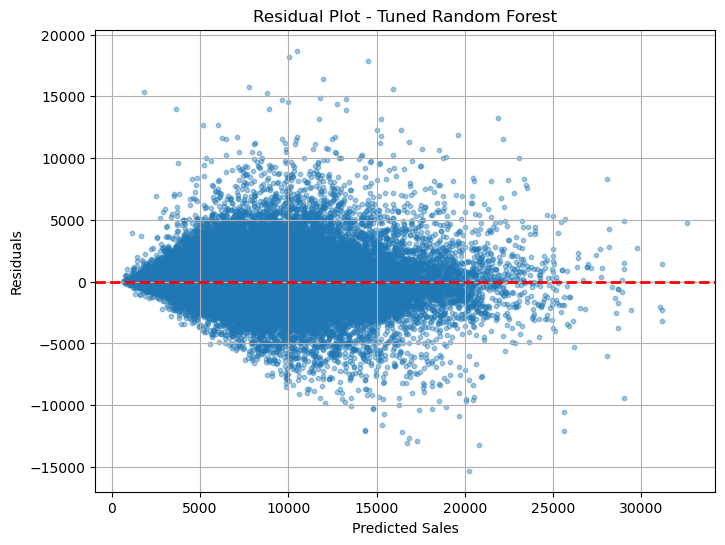

In [49]:
# Residual vs Predicted

# Predictions
y_pred = best_rf.predict(X_test)

# Residuals
residuals = y_test - y_pred

# Plot
plt.figure(figsize=(8,6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.4,
    s=10
)

# Zero-error reference line
plt.axhline(
    y=0,
    color='red',
    linestyle='--',
    linewidth=2
)

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot - Tuned Random Forest")

plt.grid(True)

plt.show()

### Feature Importance

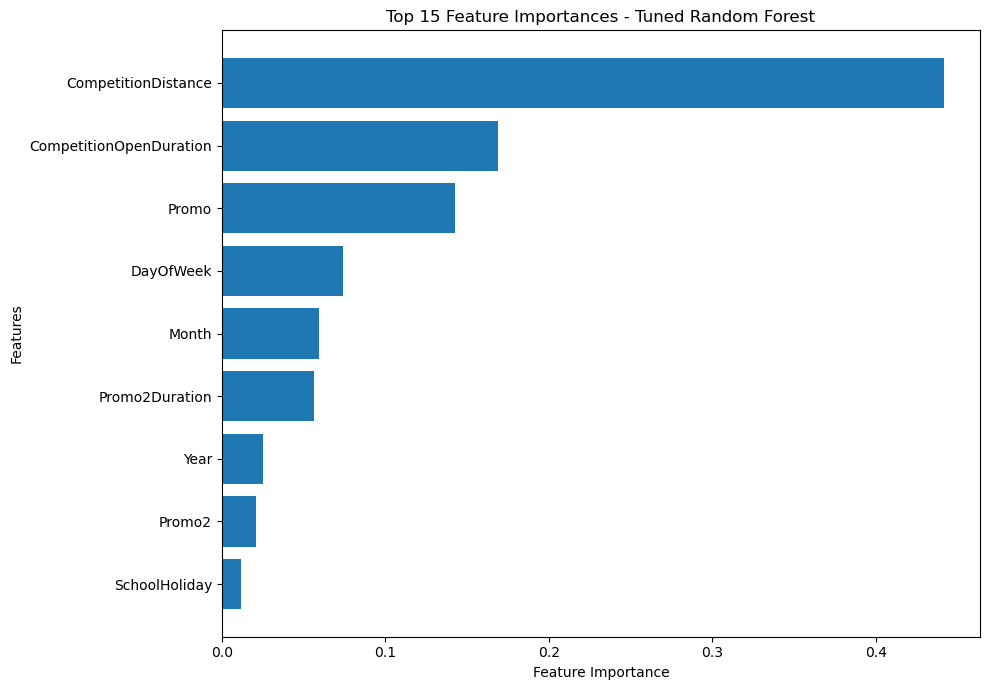

In [47]:
# Extract feature importance
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
})

# Sort from highest to lowest
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,7))

plt.barh(
    feature_importance["Feature"][:15][::-1],
    feature_importance["Importance"][:15][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 15 Feature Importances - Tuned Random Forest")

plt.tight_layout()
plt.show()

**Model Interpretation**

1. **OLS Regression:**

   The Ordinary Least Squares (OLS) regression model achieved an **R² of approximately 0.23**, indicating that the selected predictors explain approximately 23% of the variation in store sales. While most variables were statistically significant (p < 0.05), the relatively low R² suggests that the relationship between the predictors and sales is largely nonlinear. Promotion-related variables had the strongest positive influence on sales, while competition distance exhibited a small negative relationship. Store type and assortment variables also contributed significantly to explaining sales variation. Overall, the OLS model provides valuable business insights and interpretable relationships but serves primarily as a statistical benchmark rather than the final predictive model.

---

2. **Baseline Model Comparison**

   Linear Regression served as the baseline model but demonstrated relatively poor predictive performance, indicating that a simple linear relationship is insufficient for modeling retail sales. XGBoost improved predictive accuracy over Linear Regression but did not outperform Random Forest. Random Forest achieved the highest Test R² and the lowest prediction errors among the baseline models, making it the strongest candidate for further optimization.

---

3. **Hyperparameter Tuning**

   Hyperparameter tuning was performed exclusively on the Random Forest model because it demonstrated the best baseline performance. The tuning process optimized the model's complexity by adjusting parameters such as tree depth, minimum leaf size, and minimum split size. Although the tuned model produced a slightly lower training accuracy, it achieved higher testing accuracy and lower prediction errors, indicating improved generalization and reduced overfitting.

---

4. **Baseline vs. Tuned Random Forest**

   Comparing the baseline and tuned Random Forest models demonstrates the effectiveness of hyperparameter tuning. The tuned model increased the **Test R² from 0.8462 to 0.8545**, reduced the **Test MAE from 773.63 to 750.49**, and lowered the **Test RMSE from 1218.12 to 1184.73**. Additionally, the difference between the training and testing R² decreased from **0.1021 to 0.0797**, indicating that the tuned model generalizes better to unseen data while reducing overfitting. Although the training R² decreased slightly, this reflects a reduction in model complexity rather than a decline in predictive capability.

---

5. **Actual vs. Predicted Sales:**

   The Actual vs. Predicted plot demonstrates that the tuned Random Forest model closely follows the ideal 45-degree reference line, indicating strong predictive accuracy. Most observations lie near the reference line, confirming that the model produces accurate predictions across the majority of sales values. Prediction variability increases slightly for stores with exceptionally high sales, suggesting that forecasting extreme sales values remains more challenging. This behavior is expected in retail forecasting because unusually high sales are often influenced by factors such as major promotions, seasonal demand, or external events that may not be fully represented within the available dataset. Overall, the plot confirms that the tuned Random Forest model provides reliable and accurate sales forecasts.

---

6. **Residual Analysis**

   The residual plot shows that prediction errors are centered around zero without any obvious systematic trend or curvature. This indicates that the tuned Random Forest model does not consistently overestimate or underestimate sales. The residuals appear to be randomly distributed, suggesting that the model successfully captures the underlying relationships between the predictors and store sales. A slight increase in residual variability is observed for larger predicted sales values, indicating that forecasting extremely high sales is inherently more difficult. Several outliers are present; however, considering the dataset contains over **844,000 observations**, these isolated observations are expected and do not indicate model instability. Overall, the residual analysis supports the conclusion that the tuned Random Forest model generalizes well to unseen data.

---

7. **Feature Importance**

   Feature importance analysis identifies the variables that contributed most to the Random Forest model's predictions. Variables with the highest importance scores had the greatest influence on forecasting sales, while lower-ranked variables contributed relatively little predictive information. Promotion-related variables, store characteristics, competition variables, and calendar-based features collectively accounted for the majority of the model's predictive power. These findings indicate that promotional activities, store format, competition, and seasonality are the primary business drivers influencing retail sales. Understanding these key predictors provides valuable insights for inventory planning, promotional strategy, and operational decision-making.

---

8. **Final Model Selection**

   The tuned Random Forest model was selected as the final forecasting model because it demonstrated the strongest overall predictive performance while maintaining good generalization. Compared with the baseline Random Forest, hyperparameter tuning improved predictive accuracy on unseen data by increasing the Test R², reducing both MAE and RMSE, and decreasing the gap between training and testing performance. These improvements indicate that the tuned model is less prone to overfitting while providing more accurate forecasts for future sales observations.

## Conclusion

**Conclusion**
* This project successfully developed and evaluated machine learning models to forecast Rossmann store sales and identify the key business factors influencing retail performance. Following data cleaning, exploratory data analysis, feature engineering, and statistical modeling, three predictive models—Linear Regression, Random Forest, and XGBoost—were compared. While Linear Regression provided interpretable relationships between business variables and sales, its predictive performance was limited due to the nonlinear nature of retail sales data.
* Among the machine learning models, Random Forest achieved the strongest baseline performance and was selected for hyperparameter tuning. After optimization, the tuned Random Forest produced the highest predictive accuracy with a **Test R² of 0.8545**, a **Test MAE of 750.49**, and a **Test RMSE of 1184.73**, while also reducing overfitting compared to the baseline model. Visual evaluation through the Actual vs. Predicted and Residual plots further confirmed that the model generalized well to unseen data and produced accurate predictions across most sales ranges.
* Feature importance analysis demonstrated that promotional activities, store characteristics, competition, and calendar-related variables were the primary drivers of sales. These findings highlight the importance of combining operational, promotional, and seasonal information when forecasting retail demand.
* Overall, the tuned Random Forest model provides a reliable forecasting solution that can support business decision-making by improving demand forecasting accuracy, inventory planning, promotional evaluation, and resource allocation across retail stores.

---

**Business Recommendations**


1. Optimize Promotional Campaigns
Promotion-related variables were among the strongest predictors of sales. Retail managers should continue using promotions strategically while monitoring their effectiveness across different store types and seasons. Machine learning forecasts can help estimate the expected sales lift before launching future campaigns.
2. Improve Inventory Planning
Accurate sales forecasts allow inventory levels to better match expected demand, reducing both stock shortages and excess inventory. High-demand periods identified by the model should receive additional inventory allocations to improve product availability and customer satisfaction.
3. Incorporate Competition into Store Strategy
Competition distance significantly influenced store performance. Stores located closer to competitors may require different pricing, promotional strategies, or product assortments compared to stores operating in less competitive markets.
4. Use Seasonal Forecasting for Workforce Planning
Calendar variables, holidays, and seasonal trends contributed meaningfully to sales predictions. Forecasts generated by the model can help managers schedule staffing levels more effectively during anticipated periods of high or low customer demand.
5. Prioritize High-Impact Business Drivers
Feature importance analysis identified promotions, store characteristics, and competition-related variables as the most influential predictors of sales. Decision-makers should focus improvement initiatives on these high-impact factors, as changes in these areas are most likely to influence future sales performance.
6. Continuously Retrain the Forecasting Model
Retail environments change over time due to evolving customer behavior, new competitors, and changing promotional strategies. The forecasting model should be periodically retrained using the most recent sales data to maintain predictive accuracy and adapt to new business conditions.
7. Integrate Forecasting into Business Intelligence Dashboards
The tuned Random Forest model can be integrated with Power BI dashboards to provide store managers with near real-time sales forecasts, promotional performance metrics, inventory planning insights, and trend analysis. Combining predictive analytics with interactive dashboards supports faster, data-driven decision-making throughout the organization.

---

**Future Improvements**

Although the tuned Random Forest performed well, future work could further improve forecasting accuracy by incorporating additional external variables such as weather conditions, local events, economic indicators, and regional demographics. Time-series forecasting techniques and advanced gradient boosting algorithms may also be explored to determine whether additional predictive improvements can be achieved. Finally, deploying the model as an interactive forecasting application or integrating it into enterprise business intelligence platforms would allow managers to generate real-time forecasts and support operational decision-making.